<a href="https://colab.research.google.com/github/garlich/Data/blob/main/1_Explore_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 1: Explore & Clean Data**
### Chicago Crime & Weather Analysis

Understanding the two datasets and what need to be clean up before joining the 2 datasets


In [11]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ID = 'h-project-376019'
client = bigquery.Client(project=PROJECT_ID)
print('Ready :)')

Ready :)


# Part A: Explore Crime Data
Using `bigquery-public-data.chicago_crime.crime`. 2018-2025 (8 years)

In [12]:
# A1: Schema and sample rows
query = """
SELECT *
FROM `bigquery-public-data.chicago_crime.crime`
WHERE EXTRACT(YEAR FROM date) BETWEEN 2018 AND 2025
LIMIT 10
"""
df_sample = client.query(query).to_dataframe()
print(f'Columns: {list(df_sample.columns)}')
df_sample.head(10)

Columns: ['unique_key', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate', 'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude', 'location']


,unique_key,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,27642,JG350964,2023-07-22 01:41:00+00:00,000XX E LAKE ST,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,False,False,...,42,32,01A,1176905.0,1901744.0,2023,2023-07-29 15:41:00+00:00,41.885730,-87.625821,"(41.885729587, -87.625821329)"
1,12382874,JE228908,2021-05-12 00:00:00+00:00,002XX N STATE ST,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,ALLEY,False,False,...,42,32,02,1176309.0,1902256.0,2021,2021-06-04 15:39:35+00:00,41.887148,-87.627994,"(41.887148006, -87.627994483)"
2,12750356,JF304450,2022-07-03 22:18:00+00:00,0000X E LAKE ST,0312,ROBBERY,ARMED - KNIFE / CUTTING INSTRUMENT,SMALL RETAIL STORE,False,False,...,42,32,03,1176905.0,1901744.0,2022,2023-01-03 15:40:27+00:00,41.885730,-87.625821,"(41.885729587, -87.625821329)"
3,13292878,JG522733,2023-11-30 04:00:00+00:00,001XX N STATE ST,031A,ROBBERY,ARMED - HANDGUN,CTA TRAIN,False,False,...,42,32,03,1176329.0,1901689.0,2023,2023-12-08 15:41:35+00:00,41.885592,-87.627938,"(41.885591676, -87.627938154)"
4,12949311,JG112697,2023-01-07 18:00:00+00:00,001XX N STATE ST,031A,ROBBERY,ARMED - HANDGUN,CTA TRAIN,False,False,...,42,32,03,1176330.0,1901649.0,2023,2023-08-19 15:40:26+00:00,41.885482,-87.627936,"(41.885481891, -87.627935689)"
5,13425664,JH220874,2024-04-11 06:45:00+00:00,001XX N STATE ST,0320,ROBBERY,STRONG ARM - NO WEAPON,SIDEWALK,False,False,...,42,32,03,1176330.0,1901649.0,2024,2024-12-21 15:40:46+00:00,41.885482,-87.627936,"(41.885481891, -87.627935689)"
6,13406494,JH197549,2024-03-21 20:30:00+00:00,0000X E LAKE ST,0330,ROBBERY,AGGRAVATED,STREET,False,False,...,42,32,03,1176894.0,1901744.0,2024,2024-12-21 15:40:46+00:00,41.885730,-87.625862,"(41.885729836, -87.625861723)"
7,13218380,JG433454,2023-09-21 16:38:00+00:00,001XX N WABASH AVE,0420,BATTERY,AGGRAVATED - KNIFE / CUTTING INSTRUMENT,CTA PLATFORM,True,False,...,34,32,04B,1176800.0,1900945.0,2023,2023-09-29 15:42:17+00:00,41.883539,-87.626231,"(41.883539463, -87.626231082)"
8,13391871,JH179966,2024-03-06 12:20:00+00:00,001XX N STATE ST,0420,BATTERY,AGGRAVATED - KNIFE / CUTTING INSTRUMENT,STREET,True,True,...,34,32,04B,1176352.0,1900927.0,2024,2024-12-21 15:40:46+00:00,41.883500,-87.627877,"(41.883500187, -87.627876698)"
9,11877196,JC492463,2019-10-30 16:10:00+00:00,001XX N WABASH AVE,0430,BATTERY,AGGRAVATED: OTHER DANG WEAPON,STREET,False,False,...,42,32,04B,1176800.0,1900955.0,2019,2019-11-06 15:41:57+00:00,41.883567,-87.626231,"(41.883566903, -87.62623078)"


Total of 22 columns,


*   `date`: when the crime was reported
*   `primary_type`: ROBBERY, BATTERY, etc
*   `location_description`: STREET, APARTMENT
*   `arrest`: boolean, checking whether someone was arrested
*   `domestic`: boolean, flagging domestic incidents
*   `latitude, longitude, community_area, district, ward, beat`. Spatial columns not used





   year  total_crimes  days_with_data
0  2018        269161             365
1  2019        261715             365
2  2020        212736             366
3  2021        209699             365
4  2022        240077             365
5  2023        263344             365
6  2024        259121             366
7  2025        236696             365


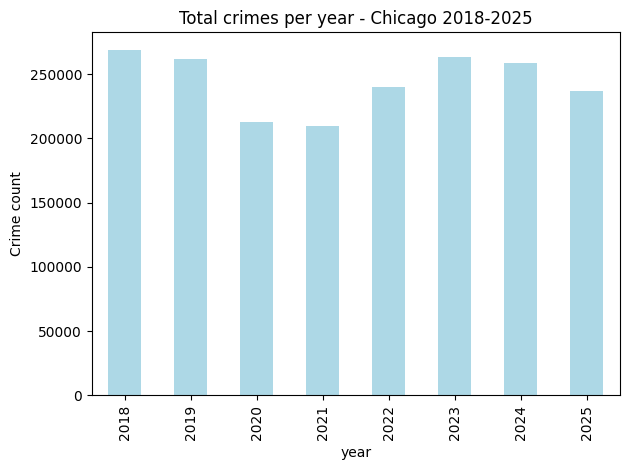

In [53]:
# A2: Checking if the data is complete. rows per year + distinct days
query = """
SELECT
  EXTRACT(YEAR FROM date) AS year,
  COUNT(*) AS total_crimes,
  COUNT(DISTINCT DATE(date)) AS days_with_data
FROM `bigquery-public-data.chicago_crime.crime`
WHERE date BETWEEN TIMESTAMP('2018-01-01') AND TIMESTAMP('2025-12-31')
GROUP BY year
ORDER BY year
"""
df_yearly = client.query(query).to_dataframe()
print(df_yearly)

df_yearly.plot(x='year', y='total_crimes', kind='bar',
               title='Total crimes per year - Chicago 2018-2025',
               legend=False, color='lightblue')
plt.ylabel('Crime count')
plt.tight_layout()
plt.show()

Each year has 365-366, not gaps. 2020 and 2021 are much lower 2018-19 (COVID lockdowns). Post-2021 the numbers grow through 2022-2025

In [14]:
# A3: what crime types exist, and how are they distributed?
query = """
SELECT
  primary_type,
  COUNT(*) AS count
FROM `bigquery-public-data.chicago_crime.crime`
WHERE date BETWEEN TIMESTAMP('2018-01-01') AND TIMESTAMP('2025-12-31')
GROUP BY primary_type
ORDER BY count DESC
"""
df_types = client.query(query).to_dataframe()
print(f'Distinct crime types: {len(df_types)}')
print(df_types.to_string())

Distinct crime types: 33
                         primary_type   count
0                               THEFT  437962
1                             BATTERY  355216
2                     CRIMINAL DAMAGE  216542
3                             ASSAULT  168104
4                  DECEPTIVE PRACTICE  141972
5                 MOTOR VEHICLE THEFT  129163
6                       OTHER OFFENSE  124905
7                            BURGLARY   70028
8                             ROBBERY   68375
9                           NARCOTICS   65187
10                  WEAPONS VIOLATION   59862
11                  CRIMINAL TRESPASS   40515
12         OFFENSE INVOLVING CHILDREN   15911
13            CRIMINAL SEXUAL ASSAULT   10468
14                        SEX OFFENSE    9965
15             PUBLIC PEACE VIOLATION    8371
16   INTERFERENCE WITH PUBLIC OFFICER    6405
17                           HOMICIDE    5122
18                              ARSON    3656
19                           STALKING    3088
20       

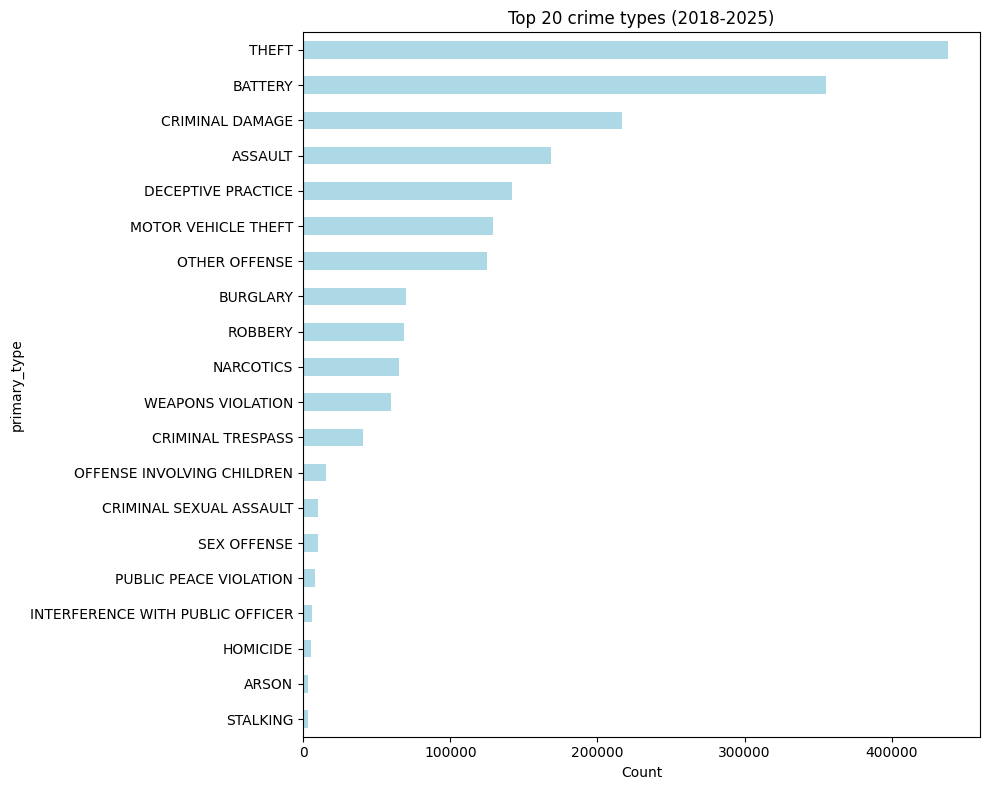

In [54]:
# top 20 visualised
fig, ax = plt.subplots(figsize=(10, 8))
df_types.head(20).plot(x='primary_type', y='count', kind='barh', ax=ax,
                      title='Top 20 crime types (2018-2025)',
                      color='lightblue', legend=False)
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

33 types, top 5 (THEFT, BATTERY, CRIMINAL DAMAGE, ASSAULT, DECEPTIVE PRACTICE).
At the bottom, RITUALISM (1 record) and NON-CRIMINAL (23 records).

In [16]:
# A4: how bad are the nulls in the key columns?
query = """
SELECT
  COUNTIF(primary_type IS NULL) AS null_primary_type,
  COUNTIF(date IS NULL) AS null_date,
  COUNTIF(location_description IS NULL) AS null_location,
  COUNTIF(arrest IS NULL) AS null_arrest,
  COUNTIF(domestic IS NULL) AS null_domestic,
  COUNTIF(latitude IS NULL) AS null_latitude,
  COUNTIF(community_area IS NULL) AS null_community_area,
  COUNT(*) AS total_rows
FROM `bigquery-public-data.chicago_crime.crime`
WHERE date BETWEEN TIMESTAMP('2018-01-01') AND TIMESTAMP('2025-12-31')
"""
df_nulls = client.query(query).to_dataframe()
print('Nulls in crime columns:')
print(df_nulls.T)

Nulls in crime columns:
                           0
null_primary_type          0
null_date                  0
null_location          10527
null_arrest                0
null_domestic              0
null_latitude          30101
null_community_area      174
total_rows           1952549


In [17]:
# A5: arrest rate and domestic rate per year
query = """
SELECT
  EXTRACT(YEAR FROM date) AS year,
  COUNT(*) AS total_crimes,
  COUNTIF(arrest = TRUE) AS arrests,
  ROUND(100 * COUNTIF(arrest = TRUE) / COUNT(*), 1) AS arrest_pct,
  COUNTIF(domestic = TRUE) AS domestic,
  ROUND(100 * COUNTIF(domestic = TRUE) / COUNT(*), 1) AS domestic_pct
FROM `bigquery-public-data.chicago_crime.crime`
WHERE date BETWEEN TIMESTAMP('2018-01-01') AND TIMESTAMP('2025-12-31')
GROUP BY year
ORDER BY year

"""
df_rates = client.query(query).to_dataframe()
print(df_rates)

   year  total_crimes  arrests  arrest_pct  domestic  domestic_pct
0  2018        269161    53927        20.0     51885          19.3
1  2019        261715    56308        21.5     51238          19.6
2  2020        212736    34211        16.1     46332          21.8
3  2021        209699    26659        12.7     47929          22.9
4  2022        240077    28252        11.8     45007          18.7
5  2023        263344    32191        12.2     47093          17.9
6  2024        259121    35847        13.8     47607          18.4
7  2025        236696    37908        16.0     45056          19.0


Arrest rate drops from 2019 onwards. Domestic percentage stays stable at 14-16% after 2019



In [18]:
# A6: location description, counts of reports
query = """
SELECT
  location_description,
  COUNT(*) AS count
FROM `bigquery-public-data.chicago_crime.crime`
WHERE date BETWEEN TIMESTAMP('2018-01-01') AND TIMESTAMP('2025-12-31')
  AND location_description IS NOT NULL
GROUP BY location_description
ORDER BY count DESC
LIMIT 25
"""
df_locations = client.query(query).to_dataframe()
print(df_locations.to_string())

                      location_description   count
0                                   STREET  495340
1                                APARTMENT  342384
2                                RESIDENCE  282567
3                                 SIDEWALK  118042
4                       SMALL RETAIL STORE   58291
5   PARKING LOT / GARAGE (NON RESIDENTIAL)   47801
6                               RESTAURANT   43476
7                                    ALLEY   42089
8                         DEPARTMENT STORE   33344
9                   VEHICLE NON-COMMERCIAL   30211
10                             GAS STATION   25897
11                         OTHER (SPECIFY)   24452
12                                   OTHER   22717
13            COMMERCIAL / BUSINESS OFFICE   22588
14                      GROCERY FOOD STORE   21349
15             RESIDENCE - PORCH / HALLWAY   18679
16         RESIDENCE - YARD (FRONT / BACK)   16109
17          PARKING LOT/GARAGE(NON.RESID.)   16001
18                      RESIDEN

STREET is by far the biggest (~500K), then APARTMENT, RESIDENCE and SIDEWALK

In [19]:
# A7: preview on how does the indoor/outdoor split look in aggregate
# Using the same categorisation that goes into v_crime_by_location
query = """
SELECT
  CASE
    WHEN location_description IN (
      'STREET', 'SIDEWALK', 'ALLEY', 'PARKING LOT / GARAGE (NON RESIDENTIAL)',
      'PARK PROPERTY', 'GAS STATION', 'HIGHWAY / EXPRESSWAY',
      'CHA PARKING LOT / GROUNDS', 'PORCH', 'YARD', 'DRIVEWAY - RESIDENTIAL',
      'BRIDGE', 'FOREST PRESERVE', 'LAKEFRONT / WATERFRONT / RIVERBANK'
    ) THEN 'outdoor'
    WHEN location_description IN (
      'APARTMENT', 'RESIDENCE', 'RESIDENCE - PORCH / HALLWAY',
      'RESIDENCE - GARAGE', 'HOTEL / MOTEL', 'SMALL RETAIL STORE',
      'GROCERY FOOD STORE', 'RESTAURANT', 'BAR OR TAVERN',
      'COMMERCIAL / BUSINESS OFFICE', 'DEPARTMENT STORE',
      'SCHOOL - PUBLIC BUILDING', 'SCHOOL - PUBLIC GROUNDS',
      'HOSPITAL BUILDING / GROUNDS', 'CONVENIENCE STORE',
      'DRUG STORE', 'BANK', 'CURRENCY EXCHANGE', 'LIBRARY',
      'GOVERNMENT BUILDING / PROPERTY'
    ) THEN 'indoor'
    WHEN location_description IS NULL THEN 'unknown'
    ELSE 'other'
  END AS location_category,
  COUNT(*) AS count
FROM `bigquery-public-data.chicago_crime.crime`
WHERE date BETWEEN TIMESTAMP('2018-01-01') AND TIMESTAMP('2025-12-31')
GROUP BY location_category
ORDER BY count DESC
"""
df_cat = client.query(query).to_dataframe()
print(df_cat)
covered = df_cat[df_cat['location_category'].isin(['indoor','outdoor'])]['count'].sum()
total = df_cat['count'].sum()
print(f'\nCoverage of indoor+outdoor categories: {100 * covered / total:.1f}%')

  location_category   count
0            indoor  919620
1           outdoor  752210
2             other  270192
3           unknown   10527

Coverage of indoor+outdoor categories: 85.6%


In [20]:
# A8: daily crime counts per year,needed for the rolling-features analysis later
# plus a proper statistical summary per year (mean, min, max, stddev)
query = """
WITH daily AS (
  SELECT DATE(date) AS d, COUNT(*) AS c
  FROM `bigquery-public-data.chicago_crime.crime`
  WHERE date BETWEEN TIMESTAMP('2018-01-01') AND TIMESTAMP('2025-12-31')
  GROUP BY d
)
SELECT
  EXTRACT(YEAR FROM d) AS year,
  COUNT(*) AS days,
  ROUND(AVG(c), 1) AS avg_daily,
  MIN(c) AS min_daily,
  MAX(c) AS max_daily,
  ROUND(STDDEV(c), 1) AS stddev_daily
FROM daily
GROUP BY year
ORDER BY year
"""
df_daily_stats = client.query(query).to_dataframe()
print(df_daily_stats)

   year  days  avg_daily  min_daily  max_daily  stddev_daily
0  2018   365      737.4        449       1038          90.2
1  2019   365      717.0        346       1159          87.6
2  2020   366      581.2        345       1901         114.9
3  2021   365      574.5        342        858          75.5
4  2022   365      657.7        393        965          97.4
5  2023   365      721.5        531       1132          68.9
6  2024   366      708.0        399       1025          76.7
7  2025   365      648.5         24        882          78.9


Standard deviation tells how much daily variation there is. 2020 has the widest spread ( lockdowns, etc.)

# **PART B: Weather Data (GSOD)**

Source `bigquery-public-data.noaa_gsod.gsod` + stations

Check stations before starting cleaning


In [21]:
# B1.1: Chicago weather stations
query = """
SELECT *
FROM `bigquery-public-data.noaa_gsod.stations`
WHERE country = 'US' AND state = 'IL'
  AND name LIKE '%CHICAGO%'
ORDER BY name
"""
df_stations = client.query(query).to_dataframe()
print(f'Found {len(df_stations)} Chicago stations')
print(df_stations[['usaf', 'wban', 'name', 'lat', 'lon', 'begin', 'end']].to_string())

Found 10 Chicago stations
     usaf   wban                          name     lat     lon     begin       end
0  997338  99999                       CHICAGO  42.000 -87.500  20080101  20210920
1  999999  94866           CHICAGO MEIGS FIELD  41.867 -87.617  19660101  19700701
2  999999  14819             CHICAGO MIDWAY AP  41.786 -87.752  19480101  19721231
3  725340  14819      CHICAGO MIDWAY INTL ARPT  41.786 -87.752  19730101  20210922
4  725300  94846  CHICAGO O'HARE INTERNATIONAL  41.960 -87.932  19461001  20210922
5  999999  94846         CHICAGO OHARE INTL AP  41.995 -87.934  19700101  19721231
6  725346  94866                 CHICAGO/MEIGS  41.867 -87.600  19730101  20080618
7  725346  99999                 CHICAGO/MEIGS  41.867 -87.600  20000101  20030409
8  725347  99999              CHICAGO/WAUKEGAN  42.417 -87.867  19890421  20051231
9  998497  99999            FOSTER AVE CHICAGO  41.976 -87.648  20120620  20201125


- The two main stations (airports) are O'Hare (725300) and Midway (725340)
- Others have codes such as 99999,999999 for usaf/wban codes

In [22]:
# B1.2: O'Hare vs Midway,row counts and average temp sanity check
query = """
SELECT
  stn,
  CASE WHEN stn = '725300' THEN 'O_Hare' WHEN stn = '725340' THEN 'Midway' END AS station,
  COUNT(*) AS rows_,
  ROUND(AVG(temp), 1) AS avg_temp_raw,
  ROUND(AVG(prcp), 2) AS avg_prcp_raw,
  ROUND(AVG(sndp), 1) AS avg_sndp_raw
FROM `bigquery-public-data.noaa_gsod.gsod*`
WHERE stn IN ('725300', '725340')
  AND CAST(year AS INT64) BETWEEN 2018 AND 2025
GROUP BY stn
ORDER BY station
"""
df_cmp = client.query(query).to_dataframe()
print(df_cmp)

      stn station  rows_  avg_temp_raw  avg_prcp_raw  avg_sndp_raw
0  725340  Midway   2796          53.7          0.10         898.7
1  725300  O_Hare   2794          52.6          0.14         877.2


* Both stations 2794 to 2796 rows over 2018/2025
* avg_temp_raw results look reasonably (52-53F) and avg_prcp_raw (0.10-0.14)
* avg_sndp_raw shows around 880, looks wrong thinking of this average of snow per day

In [23]:
# B2: raw weather sample
query = """
SELECT
  DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) AS weather_date,
  temp, dewp, slp, visib, wdsp, mxpsd, gust,
  max, min, prcp, sndp,
  fog, rain_drizzle, snow_ice_pellets, thunder
FROM `bigquery-public-data.noaa_gsod.gsod*`
WHERE stn = '725300' AND wban = '94846'
  AND CAST(year AS INT64) = 2020
ORDER BY weather_date
LIMIT 15
"""
df_raw = client.query(query).to_dataframe()
print('Raw Jan 2020 sample:')
print(df_raw.to_string())

Raw Jan 2020 sample:
   weather_date  temp  dewp     slp  visib  wdsp mxpsd   gust   max   min  prcp   sndp fog rain_drizzle snow_ice_pellets thunder
0    2020-01-01  28.3  21.8  1008.6   10.0   9.2  15.9   25.1  42.1  21.0  0.08    2.0   0            0                0       0
1    2020-01-02  41.7  30.7  1001.3   10.0  12.5  17.1   27.0  48.0  37.0  0.00  999.9   0            0                0       0
2    2020-01-03  38.4  32.9  1007.6   10.0   5.3   8.9  999.9  48.0  34.0  0.00  999.9   0            0                0       0
3    2020-01-04  31.8  25.6  1014.1    8.5   7.6  12.0   17.1  41.0  28.9  0.03    1.2   0            0                1       0
4    2020-01-05  30.7  23.9  1017.2    9.9  10.1  18.1   32.1  42.1  24.1  0.00    1.2   0            0                0       0
5    2020-01-06  33.8  22.3  1018.9   10.0  10.1  19.0   32.1  42.1  24.3  0.00  999.9   0            0                0       0
6    2020-01-07  33.9  22.3  1016.5   10.0   7.6  13.0   19.0  42.1  28.0  0

Some values of sndp and gust are 999.9, placeholder?

In [24]:
# B3: min/max the whole O'Hare 2018-2025 window
query = """
SELECT
  ROUND(MIN(temp), 1) AS min_temp,  ROUND(MAX(temp), 1) AS max_temp,
  ROUND(MIN(dewp), 1) AS min_dewp,  ROUND(MAX(dewp), 1) AS max_dewp,
  ROUND(MIN(slp), 1)  AS min_slp,   ROUND(MAX(slp), 1)  AS max_slp,
  ROUND(MIN(visib), 1) AS min_visib, ROUND(MAX(visib), 1) AS max_visib,
  ROUND(MIN(SAFE_CAST(wdsp AS FLOAT64)), 1) AS min_wdsp,
  ROUND(MAX(SAFE_CAST(wdsp AS FLOAT64)), 1) AS max_wdsp,
  ROUND(MIN(gust), 1) AS min_gust,  ROUND(MAX(gust), 1) AS max_gust,
  ROUND(MIN(max), 1)  AS min_max,   ROUND(MAX(max), 1)  AS max_max,
  ROUND(MIN(min), 1)  AS min_min,   ROUND(MAX(min), 1)  AS max_min,
  ROUND(MIN(prcp), 2) AS min_prcp,  ROUND(MAX(prcp), 2) AS max_prcp,
  ROUND(MIN(sndp), 1) AS min_sndp,  ROUND(MAX(sndp), 1) AS max_sndp
FROM `bigquery-public-data.noaa_gsod.gsod*`
WHERE stn = '725300' AND wban = '94846'
  AND CAST(year AS INT64) BETWEEN 2018 AND 2025
"""
df_ranges = client.query(query).to_dataframe()
print('Min / max per column:')
print(df_ranges.T)

Min / max per column:
                 0
min_temp    -15.00
max_temp     90.20
min_dewp    -23.80
max_dewp     78.50
min_slp     988.60
max_slp    1044.10
min_visib     0.80
max_visib    10.00
min_wdsp      1.70
max_wdsp     23.80
min_gust     14.00
max_gust    999.90
min_max      -4.00
max_max    9999.90
min_min     -23.10
max_min      81.00
min_prcp      0.00
max_prcp     99.99
min_sndp      1.20
max_sndp    999.90


NOAA GSOD documentation (https://www.ncei.noaa.gov/data/global-summary-of-the-day/doc/readme.txt) confirms missing-value codes of 999.9 (visib, wdsp, mxpsd, gust, sndp), 99.99 (missing prcp), 9999.9 (missing temp, dewp, slp, max, min)

In [25]:
# B4: count occurrences of each 'missing' code per column
query = """
SELECT
  COUNT(*) AS total_rows,
  COUNTIF(temp = 9999.9) AS missing_temp,
  COUNTIF(dewp = 9999.9) AS missing_dewp,
  COUNTIF(slp = 9999.9) AS missing_slp,
  COUNTIF(visib = 999.9) AS missing_visib,
  COUNTIF(SAFE_CAST(wdsp AS FLOAT64) = 999.9) AS missing_wdsp,
  COUNTIF(SAFE_CAST(mxpsd AS FLOAT64) = 999.9) AS missing_mxpsd,
  COUNTIF(gust = 999.9) AS missing_gust,
  COUNTIF(max = 9999.9) AS missing_max,
  COUNTIF(min = 9999.9) AS missing_min,
  COUNTIF(prcp = 99.99) AS missing_prcp,
  COUNTIF(sndp = 999.9) AS missing_sndp
FROM `bigquery-public-data.noaa_gsod.gsod*`
WHERE stn = '725300' AND wban = '94846'
  AND CAST(year AS INT64) BETWEEN 2018 AND 2025
"""
df_missing = client.query(query).to_dataframe()
total = df_missing['total_rows'].iloc[0]
pct = (df_missing.iloc[0, 1:] / total * 100).round(1)
print(f'Total rows: {total}')
print('\nMissing per column (count, %):')
for col in df_missing.columns[1:]:
    cnt = df_missing[col].iloc[0]
    print(f'  {col:20s}: {cnt:5d} ({100*cnt/total:.1f}%)')

Total rows: 2794

Missing per column (count, %):
  missing_temp        :     0 (0.0%)
  missing_dewp        :     0 (0.0%)
  missing_slp         :     0 (0.0%)
  missing_visib       :     0 (0.0%)
  missing_wdsp        :     0 (0.0%)
  missing_mxpsd       :     0 (0.0%)
  missing_gust        :   722 (25.8%)
  missing_max         :     1 (0.0%)
  missing_min         :     0 (0.0%)
  missing_prcp        :     1 (0.0%)
  missing_sndp        :  2450 (87.7%)


In [26]:
# B5: checking if the `date` column reliable across 2018-2025
query = """
SELECT CAST(year AS INT64) AS yr, COUNT(*) AS rows_,
       COUNTIF(date IS NULL) AS null_date
FROM `bigquery-public-data.noaa_gsod.gsod*`
WHERE stn = '725300' AND wban = '94846'
  AND CAST(year AS INT64) BETWEEN 2018 AND 2025
GROUP BY yr ORDER BY yr
"""
print(client.query(query).to_dataframe())

     yr  rows_  null_date
0  2018    365        365
1  2019    365        365
2  2020    366          0
3  2021    365          0
4  2022    365          0
5  2023    365          0
6  2024    366          0
7  2025    237          0


- 2018 and 2019 have date 100% NULL, need to rebuild from year/mo/da instead
- 2025 only has 237 rows, not 365, maybe GSOD publication lag


Switching the window to 2017-2024 (8 complete years) rather than fighting with partial 2025

In [27]:
# B6: rows per year for O'Hare station to confirm 2017-2024 coverage
query = """
SELECT year, COUNT(*) AS row_count
FROM `bigquery-public-data.noaa_gsod.gsod*`
WHERE stn = '725300' AND wban = '94846'
  AND CAST(year AS INT64) BETWEEN 2017 AND 2024
GROUP BY year
ORDER BY year
"""
print(client.query(query).to_dataframe())

   year  row_count
0  2017        365
1  2018        365
2  2019        365
3  2020        366
4  2021        365
5  2022        365
6  2023        365
7  2024        366


In [28]:
# B6b: check for missing dates across 2017-2024
# (e.g a year could have 365 rows but be missing Feb 15 with Feb 14 twice)
query = """
WITH weather_dates AS (
  SELECT DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) AS d
  FROM `bigquery-public-data.noaa_gsod.gsod*`
  WHERE stn = '725300' AND wban = '94846'
    AND CAST(year AS INT64) BETWEEN 2017 AND 2024
),
all_dates AS (
  SELECT d AS expected
  FROM UNNEST(GENERATE_DATE_ARRAY('2017-01-01', '2024-12-31')) AS d
)
SELECT expected AS missing_date
FROM all_dates
LEFT JOIN weather_dates ON all_dates.expected = weather_dates.d
WHERE weather_dates.d IS NULL
ORDER BY expected
"""
missing = client.query(query).to_dataframe()
if len(missing) == 0:
    print('Weather series is complete across 2017-2024. no missing dates.')
else:
    print(f'{len(missing)} missing dates:')
    print(missing)

Weather series is complete across 2017-2024. no missing dates.


the `CASE WHEN` swaps for NULL, and the resulting min/max/mean for temperature look like real Chicago values rather than 5000+ F.


In [29]:
# B7: quick test to clean just temp and prcp on a small sample, confirm it works
query = """
SELECT
  DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) AS weather_date,
  CASE WHEN temp = 9999.9 THEN NULL ELSE temp END AS mean_temp_f,
  CASE WHEN prcp = 99.99  THEN NULL ELSE prcp END AS precipitation_in
FROM `bigquery-public-data.noaa_gsod.gsod*`
WHERE stn = '725300' AND wban = '94846'
  AND CAST(year AS INT64) BETWEEN 2017 AND 2024
ORDER BY weather_date
"""
df_weather = client.query(query).to_dataframe()
print(f'Shape: {df_weather.shape}')
print(f'Nulls after cleaning:')
print(df_weather.isnull().sum())
print(f'Temp stats : min={df_weather["mean_temp_f"].min():.1f}, max={df_weather["mean_temp_f"].max():.1f}, mean={df_weather["mean_temp_f"].mean():.1f}')

Shape: (2922, 3)
Nulls after cleaning:
weather_date        0
mean_temp_f         0
precipitation_in    1
dtype: int64
Temp stats : min=-15.0, max=90.2, mean=52.6


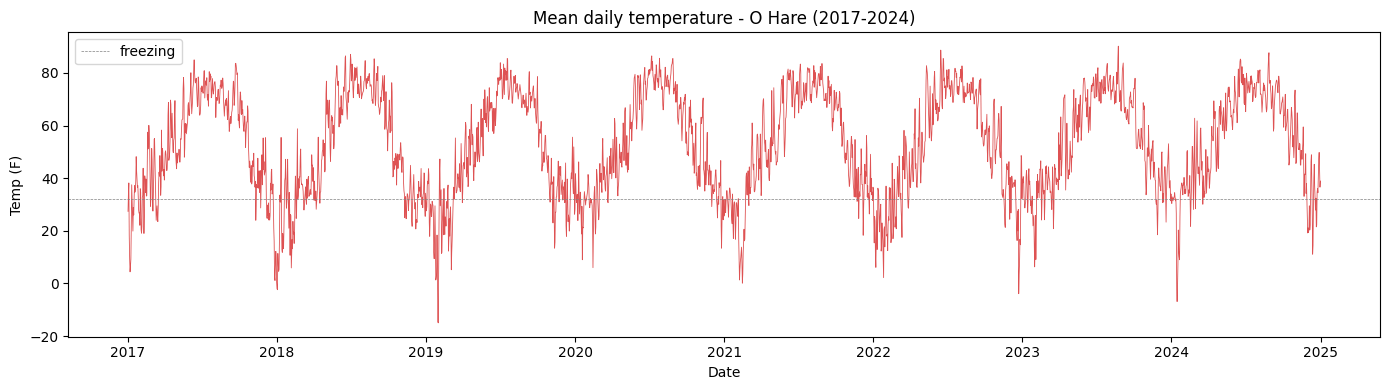

In [30]:
# B8: checking the temperature to make sure it looks like Chicago weather
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_weather['weather_date'], df_weather['mean_temp_f'],
        linewidth=0.6, color='tab:red', alpha=0.8)
ax.axhline(32, color='gray', linestyle='--', linewidth=0.5, label='freezing')
ax.set_title('Mean daily temperature - O Hare (2017-2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Temp (F)')
ax.legend()
plt.tight_layout()
plt.show()

# **PART C: Quick previews of the analytical dimensions**

Previews to confirm each dimension to see if this is worth the effort before building the full view. Using a quick join of crime counts and weather

In [51]:
# C: quick combined from the cleaned weather in B5b + a simple daily crime aggregate

# daily crime counts including indoor/outdoor split
crime_query = """
SELECT
  DATE(date) AS crime_date,
  COUNT(*) AS total_crimes,
  COUNTIF(domestic = TRUE) AS domestic_crimes,
  COUNTIF(primary_type = 'THEFT')   AS theft,
  COUNTIF(primary_type = 'BATTERY') AS battery,
  COUNTIF(primary_type = 'ASSAULT') AS assault,
  COUNTIF(location_description IN ('STREET','SIDEWALK','ALLEY','PARK PROPERTY'))
    AS outdoor_count,
  COUNTIF(location_description IN ('APARTMENT','RESIDENCE','HOTEL / MOTEL','RESTAURANT'))
    AS indoor_count
FROM `bigquery-public-data.chicago_crime.crime`
WHERE date BETWEEN TIMESTAMP('2017-01-01') AND TIMESTAMP('2024-12-31')
GROUP BY crime_date
"""
df_crime = client.query(crime_query).to_dataframe()

# merge with the cleaned weather from B5b (already in df_weather)
df = df_crime.merge(df_weather, left_on='crime_date', right_on='weather_date')
df['year']  = pd.to_datetime(df['crime_date']).dt.year
df['month'] = pd.to_datetime(df['crime_date']).dt.month
df['dow']   = pd.to_datetime(df['crime_date']).dt.dayofweek + 1  # 1=Mon
print(f'Preview dataset: {df.shape}')
df.head()

Preview dataset: (2922, 14)


,crime_date,total_crimes,domestic_crimes,theft,battery,assault,outdoor_count,indoor_count,weather_date,mean_temp_f,precipitation_in,year,month,dow
0,2019-12-02,710,123,200,107,50,216,225,2019-12-02,31.7,0.11,2019,12,1
1,2024-04-11,689,113,155,117,64,219,246,2024-04-11,55.6,0.00,2024,4,4
2,2018-08-02,856,136,266,150,50,307,236,2018-08-02,76.8,0.00,2018,8,4
3,2024-03-30,645,126,156,121,67,233,225,2024-03-30,48.2,0.43,2024,3,6
4,2022-08-06,752,158,156,148,64,301,241,2022-08-06,82.7,0.00,2022,8,6


### Dimension 1: outdoor vs indoor crime, respond differently to temperature

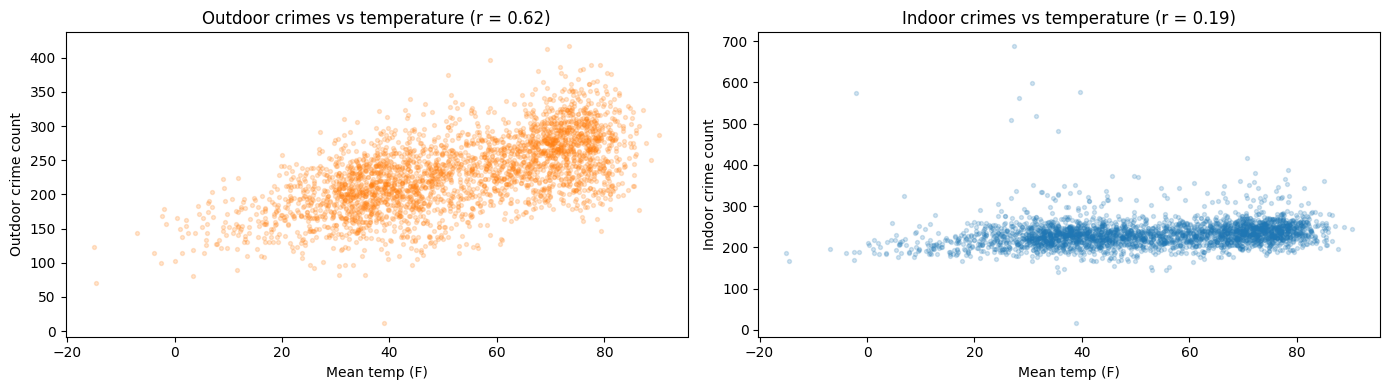


Outdoor r = 0.624, Indoor r = 0.187


In [52]:
# C1: preview dim 1, outdoor vs indoor vs temperature
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# outdoor
axes[0].scatter(df['mean_temp_f'], df['outdoor_count'], alpha=0.2, s=8, color='tab:orange')
corr_out = df[['mean_temp_f','outdoor_count']].corr().iloc[0,1]
axes[0].set_title(f'Outdoor crimes vs temperature (r = {corr_out:.2f})')
axes[0].set_xlabel('Mean temp (F)')
axes[0].set_ylabel('Outdoor crime count')

# indoor
axes[1].scatter(df['mean_temp_f'], df['indoor_count'], alpha=0.2, s=8, color='tab:blue')
corr_in = df[['mean_temp_f','indoor_count']].corr().iloc[0,1]
axes[1].set_title(f'Indoor crimes vs temperature (r = {corr_in:.2f})')
axes[1].set_xlabel('Mean temp (F)')
axes[1].set_ylabel('Indoor crime count')

plt.tight_layout()
plt.show()
print(f'\nOutdoor r = {corr_out:.3f}, Indoor r = {corr_in:.3f}')

### Dimension 2: different crime types vs differently to weather

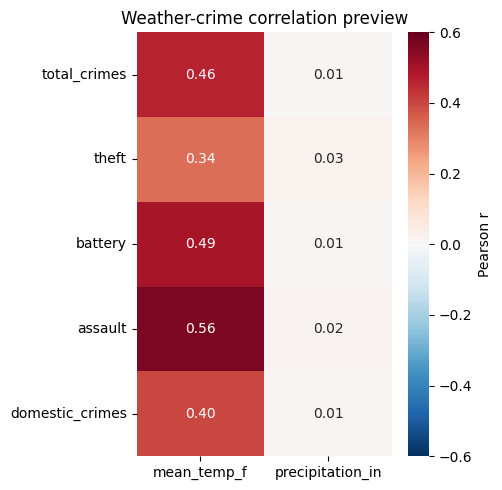

In [33]:
# C2: preview dim 2, which crime types correlate with temperature / rain?
crime_cols = ['total_crimes', 'theft', 'battery', 'assault', 'domestic_crimes']
weather_cols = ['mean_temp_f', 'precipitation_in']

corr_matrix = df[crime_cols + weather_cols].corr().loc[crime_cols, weather_cols]

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, cbar_kws={'label': 'Pearson r'}, vmin=-0.6, vmax=0.6)
ax.set_title('Weather-crime correlation preview')
plt.tight_layout()
plt.show()

### Dimension 3: COVID relationship

/tmp/ipykernel_11435/980840256.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_by_period = df.groupby('covid_period', observed=True).apply(


Temperature vs total_crimes correlation by period:
covid_period
pre_covid (2017-19)     0.672
covid (2020-21)         0.359
post_covid (2022-24)    0.653
dtype: float64


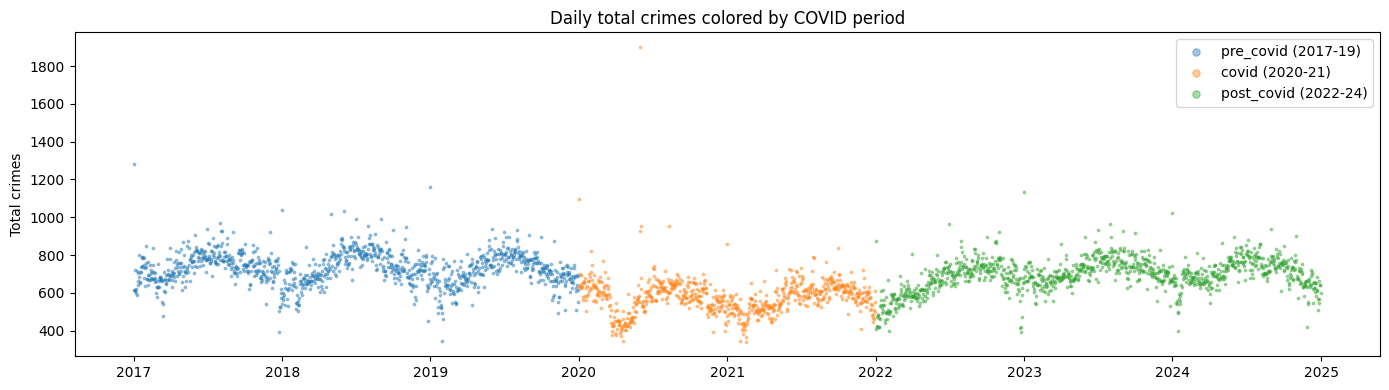

In [34]:
# C3: preview dim 3, does temp-crime correlation change across COVID periods?
df['covid_period'] = pd.cut(df['year'],
                             bins=[2016, 2019, 2021, 2024],
                             labels=['pre_covid (2017-19)', 'covid (2020-21)', 'post_covid (2022-24)'])

corr_by_period = df.groupby('covid_period', observed=True).apply(
    lambda g: g[['mean_temp_f','total_crimes']].corr().iloc[0,1]
)
print('Temperature vs total_crimes correlation by period:')
print(corr_by_period.round(3))

# plot daily crime over time with the three periods visible
fig, ax = plt.subplots(figsize=(14, 4))
for period, g in df.groupby('covid_period', observed=True):
    ax.scatter(g['crime_date'], g['total_crimes'], s=3, alpha=0.4, label=str(period))
ax.set_title('Daily total crimes colored by COVID period')
ax.set_ylabel('Total crimes')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

### Dimension 4: lag and rolling features

In [35]:
# C4: preview dim 4, does today's, yesterday's, or 3-day-rolling temp correlate best?
df_sorted = df.sort_values('crime_date').reset_index(drop=True)
df_sorted['temp_yesterday'] = df_sorted['mean_temp_f'].shift(1)
df_sorted['temp_3d_avg']    = df_sorted['mean_temp_f'].rolling(3).mean()
df_sorted['temp_7d_avg']    = df_sorted['mean_temp_f'].rolling(7).mean()

comparison = pd.DataFrame({
    'feature': ['temp_today', 'temp_yesterday', 'temp_3d_avg', 'temp_7d_avg'],
    'correlation with total_crimes': [
        df_sorted['mean_temp_f'].corr(df_sorted['total_crimes']),
        df_sorted['temp_yesterday'].corr(df_sorted['total_crimes']),
        df_sorted['temp_3d_avg'].corr(df_sorted['total_crimes']),
        df_sorted['temp_7d_avg'].corr(df_sorted['total_crimes']),
    ]
})
print(comparison.round(3))

          feature  correlation with total_crimes
0      temp_today                          0.460
1  temp_yesterday                          0.439
2     temp_3d_avg                          0.453
3     temp_7d_avg                          0.442


### Dimension 5: day-of-week effect is strong enough to warrant inclusion

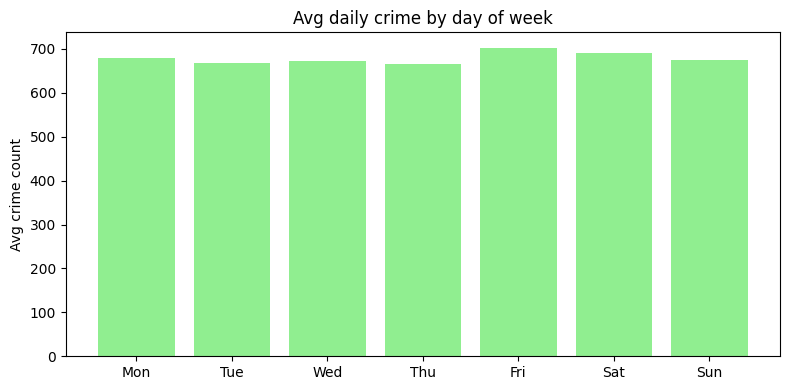


Busiest: Fri (703)
Quietest: Thu (666)
Gap: 36 crimes/day


In [55]:
# C5: preview dim 5, day of week effect
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_avg = df.groupby('dow')['total_crimes'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow_labels, dow_avg.values, color='lightgreen')
ax.set_title('Avg daily crime by day of week')
ax.set_ylabel('Avg crime count')
plt.tight_layout()
plt.show()

print(f'\nBusiest: {dow_labels[dow_avg.values.argmax()]} ({dow_avg.max():.0f})')
print(f'Quietest: {dow_labels[dow_avg.values.argmin()]} ({dow_avg.min():.0f})')
print(f'Gap: {dow_avg.max() - dow_avg.min():.0f} crimes/day')

---
# D: Build views & export CSV

Chicago Crime & Weather Analysis
Window: 2017-2024 (pivoted from 2018-2025  because of partial 2025 data)




In [37]:
# D1: create the dataset if it doesn't exist
sql_setup = '''
CREATE SCHEMA IF NOT EXISTS `h-project-376019.chicago_crime_weather`
OPTIONS (
  location = 'US',
  description = "Chicago crime + O'Hare weather analysis (2017-2024)"
)
'''
client.query(sql_setup).result()
print('dataset ready')

dataset ready


In [38]:
# D2: View 1: daily crime counts
sql_v1 = '''
CREATE OR REPLACE VIEW `h-project-376019.chicago_crime_weather.v_daily_crime_counts` AS
SELECT
  DATE(date)                                AS crime_date,
  COUNT(*)                                  AS total_crimes,
  COUNTIF(arrest = TRUE)                    AS total_arrests,
  COUNTIF(domestic = TRUE)                  AS domestic_crimes,
  EXTRACT(DAYOFWEEK FROM date)              AS day_of_week,
  EXTRACT(MONTH FROM date)                  AS month,
  EXTRACT(YEAR FROM date)                   AS year,
  EXTRACT(DAYOFYEAR FROM date)              AS day_of_year,
  CASE WHEN EXTRACT(DAYOFWEEK FROM date) IN (1, 7) THEN 1 ELSE 0 END AS is_weekend
FROM `bigquery-public-data.chicago_crime.crime`
WHERE date BETWEEN TIMESTAMP('2017-01-01') AND TIMESTAMP('2024-12-31')
GROUP BY crime_date, day_of_week, month, year, day_of_year, is_weekend
'''
client.query(sql_v1).result()
print('v_daily_crime_counts created')

v_daily_crime_counts created


In [39]:
# D3: View 2: crime by type
sql_v2 = '''
CREATE OR REPLACE VIEW `h-project-376019.chicago_crime_weather.v_crime_by_type` AS
SELECT
  DATE(date)   AS crime_date,
  primary_type,
  COUNT(*)     AS count
FROM `bigquery-public-data.chicago_crime.crime`
WHERE date BETWEEN TIMESTAMP('2017-01-01') AND TIMESTAMP('2024-12-31')
GROUP BY crime_date, primary_type
'''
client.query(sql_v2).result()
print('v_crime_by_type created')

v_crime_by_type created


In [40]:
# D4: View 3: crime by location, with indoor/outdoor tag
sql_v3 = '''
CREATE OR REPLACE VIEW `h-project-376019.chicago_crime_weather.v_crime_by_location` AS
SELECT
  DATE(date)            AS crime_date,
  location_description,
  CASE
    WHEN location_description IN (
      'STREET', 'SIDEWALK', 'ALLEY', 'PARKING LOT / GARAGE (NON RESIDENTIAL)',
      'PARK PROPERTY', 'GAS STATION', 'HIGHWAY / EXPRESSWAY',
      'CHA PARKING LOT / GROUNDS', 'PORCH', 'YARD', 'DRIVEWAY - RESIDENTIAL',
      'BRIDGE', 'FOREST PRESERVE', 'LAKEFRONT / WATERFRONT / RIVERBANK'
    ) THEN 'outdoor'
    WHEN location_description IN (
      'APARTMENT', 'RESIDENCE', 'RESIDENCE - PORCH / HALLWAY',
      'RESIDENCE - GARAGE', 'HOTEL / MOTEL', 'SMALL RETAIL STORE',
      'GROCERY FOOD STORE', 'RESTAURANT', 'BAR OR TAVERN',
      'COMMERCIAL / BUSINESS OFFICE', 'DEPARTMENT STORE',
      'SCHOOL - PUBLIC BUILDING', 'SCHOOL - PUBLIC GROUNDS',
      'HOSPITAL BUILDING / GROUNDS', 'CONVENIENCE STORE',
      'DRUG STORE', 'BANK', 'CURRENCY EXCHANGE', 'LIBRARY',
      'GOVERNMENT BUILDING / PROPERTY'
    ) THEN 'indoor'
    ELSE 'other'
  END                    AS location_category,
  COUNT(*)               AS count
FROM `bigquery-public-data.chicago_crime.crime`
WHERE date BETWEEN TIMESTAMP('2017-01-01') AND TIMESTAMP('2024-12-31')
  AND location_description IS NOT NULL
GROUP BY crime_date, location_description, location_category
'''
client.query(sql_v3).result()
print('v_crime_by_location created')

v_crime_by_location created


In [41]:
# D5: View 4: cleaned O'Hare daily weather
# placeholder codes changed to NULL. date rebuilt from year/mo/da.
sql_v4 = '''
CREATE OR REPLACE VIEW `h-project-376019.chicago_crime_weather.v_daily_weather` AS
SELECT
  DATE(CAST(d.year AS INT64), CAST(d.mo AS INT64), CAST(d.da AS INT64)) AS weather_date,
  CASE WHEN d.temp  = 9999.9 THEN NULL ELSE d.temp END AS mean_temp_f,
  CASE WHEN d.min   = 9999.9 THEN NULL ELSE d.min  END AS min_temp_f,
  CASE WHEN d.max   = 9999.9 THEN NULL ELSE d.max  END AS max_temp_f,
  CASE WHEN d.dewp  = 9999.9 THEN NULL ELSE d.dewp END AS dew_point_f,
  CASE WHEN d.slp   = 9999.9 THEN NULL ELSE d.slp  END AS sea_level_pressure,
  CASE WHEN d.visib = 999.9  THEN NULL ELSE d.visib END AS visibility_miles,
  CASE WHEN SAFE_CAST(d.wdsp AS FLOAT64)  = 999.9 THEN NULL
       ELSE SAFE_CAST(d.wdsp AS FLOAT64)  END AS wind_speed_knots,
  CASE WHEN SAFE_CAST(d.mxpsd AS FLOAT64) = 999.9 THEN NULL
       ELSE SAFE_CAST(d.mxpsd AS FLOAT64) END AS max_wind_speed_knots,
  CASE WHEN d.gust  = 999.9  THEN NULL ELSE d.gust END AS gust_speed_knots,
  CASE WHEN d.prcp  = 99.99  THEN NULL ELSE d.prcp END AS precipitation_in,
  CASE WHEN d.sndp  = 999.9  THEN NULL ELSE d.sndp END AS snow_depth_in,
  d.fog, d.rain_drizzle, d.snow_ice_pellets, d.thunder
FROM `bigquery-public-data.noaa_gsod.gsod*` AS d
WHERE d.stn  = '725300'
  AND d.wban = '94846'
  AND CAST(d.year AS INT64) BETWEEN 2017 AND 2024
  AND d.temp != 9999.9
'''
client.query(sql_v4).result()
print('v_daily_weather created')

v_daily_weather created


In [42]:
# D6: View 5: final combined dataset (joins views 1, 3, 4)
# top 10 crime types as columns, outdoor/indoor counts, calendar features, weather
# ref: https://www.w3schools.com/sql/func_sqlserver_coalesce.asp

sql_v5 = '''
CREATE OR REPLACE VIEW `h-project-376019.chicago_crime_weather.v_daily_combined` AS
WITH daily_crime AS (
  SELECT
    DATE(date) AS crime_date,
    COUNT(*)                                     AS total_crimes,
    COUNTIF(arrest = TRUE)                       AS total_arrests,
    COUNTIF(domestic = TRUE)                     AS domestic_crimes,
    COUNTIF(primary_type = 'THEFT')              AS theft_count,
    COUNTIF(primary_type = 'BATTERY')            AS battery_count,
    COUNTIF(primary_type = 'CRIMINAL DAMAGE')    AS damage_count,
    COUNTIF(primary_type = 'ASSAULT')            AS assault_count,
    COUNTIF(primary_type = 'DECEPTIVE PRACTICE') AS deceptive_count,
    COUNTIF(primary_type = 'OTHER OFFENSE')      AS other_offense_count,
    COUNTIF(primary_type = 'NARCOTICS')          AS narcotics_count,
    COUNTIF(primary_type = 'BURGLARY')           AS burglary_count,
    COUNTIF(primary_type = 'MOTOR VEHICLE THEFT') AS motor_theft_count,
    COUNTIF(primary_type = 'ROBBERY')            AS robbery_count
  FROM `bigquery-public-data.chicago_crime.crime`
  WHERE date BETWEEN TIMESTAMP('2017-01-01') AND TIMESTAMP('2024-12-31')
  GROUP BY crime_date
),
daily_location AS (
  SELECT
    crime_date,
    SUM(IF(location_category = 'outdoor', count, 0)) AS outdoor_count,
    SUM(IF(location_category = 'indoor',  count, 0)) AS indoor_count,
    SUM(IF(location_category = 'other',   count, 0)) AS other_location_count
  FROM `h-project-376019.chicago_crime_weather.v_crime_by_location`
  GROUP BY crime_date
)
SELECT
  c.crime_date,
  EXTRACT(DAYOFWEEK  FROM c.crime_date) AS day_of_week,
  EXTRACT(MONTH      FROM c.crime_date) AS month,
  EXTRACT(YEAR       FROM c.crime_date) AS year,
  EXTRACT(DAYOFYEAR  FROM c.crime_date) AS day_of_year,
  CASE WHEN EXTRACT(DAYOFWEEK FROM c.crime_date) IN (1, 7) THEN 1 ELSE 0 END AS is_weekend,
  CASE
    WHEN FORMAT_DATE('%m-%d', c.crime_date) IN ('01-01','07-04','11-11','12-25') THEN 1
    WHEN EXTRACT(MONTH FROM c.crime_date) = 11
     AND EXTRACT(DAYOFWEEK FROM c.crime_date) = 5
     AND EXTRACT(DAY FROM c.crime_date) BETWEEN 22 AND 28 THEN 1
    ELSE 0
  END AS is_holiday,
  c.total_crimes, c.total_arrests, c.domestic_crimes,
  c.theft_count, c.battery_count, c.damage_count, c.assault_count,
  c.deceptive_count, c.other_offense_count, c.narcotics_count,
  c.burglary_count, c.motor_theft_count, c.robbery_count,
  COALESCE(l.outdoor_count, 0)        AS outdoor_count,
  COALESCE(l.indoor_count, 0)         AS indoor_count,
  COALESCE(l.other_location_count, 0) AS other_location_count,
  w.mean_temp_f, w.min_temp_f, w.max_temp_f, w.dew_point_f,
  w.sea_level_pressure, w.visibility_miles, w.wind_speed_knots,
  w.max_wind_speed_knots, w.gust_speed_knots,
  w.precipitation_in, w.snow_depth_in,
  w.fog, w.rain_drizzle, w.snow_ice_pellets, w.thunder
FROM daily_crime c
LEFT JOIN daily_location l ON c.crime_date = l.crime_date
INNER JOIN `h-project-376019.chicago_crime_weather.v_daily_weather` w
  ON c.crime_date = w.weather_date
'''
client.query(sql_v5).result()
print('v_daily_combined created')

v_daily_combined created


In [43]:
# D7: confirm all 5 views exist
query = '''
SELECT table_name, table_type
FROM `h-project-376019.chicago_crime_weather.INFORMATION_SCHEMA.TABLES`
WHERE table_type = 'VIEW'
ORDER BY table_name
'''
client.query(query).to_dataframe()

,table_name,table_type
0,v_crime_by_location,VIEW
1,v_crime_by_type,VIEW
2,v_daily_combined,VIEW
3,v_daily_crime_counts,VIEW
4,v_daily_weather,VIEW


---

# E: Pull the combined view + save CSVs

In [44]:
# E1: pull the combined view into pandas
df_combined = client.query(
    'SELECT * FROM `h-project-376019.chicago_crime_weather.v_daily_combined` ORDER BY crime_date'
).to_dataframe()
print(f'Shape: {df_combined.shape}')
print(f'Date range: {df_combined["crime_date"].min()} to {df_combined["crime_date"].max()}')
df_combined.head()

Shape: (2922, 38)
Date range: 2017-01-01 to 2024-12-31


,crime_date,day_of_week,month,year,day_of_year,is_weekend,is_holiday,total_crimes,total_arrests,domestic_crimes,...,visibility_miles,wind_speed_knots,max_wind_speed_knots,gust_speed_knots,precipitation_in,snow_depth_in,fog,rain_drizzle,snow_ice_pellets,thunder
0,2017-01-01,1,1,2017,1,1,1,1281,168,416,...,9.5,4.5,11.1,15.9,0.00,NaN,0,0,0,0
1,2017-01-02,2,1,2017,2,0,0,613,110,131,...,7.2,5.2,8.0,NaN,0.00,NaN,0,1,0,0
2,2017-01-03,3,1,2017,3,0,0,721,133,137,...,2.4,5.9,18.1,22.9,0.11,NaN,1,1,0,0
3,2017-01-04,4,1,2017,4,0,0,614,108,116,...,9.7,14.9,18.1,28.0,0.00,NaN,0,0,0,0
4,2017-01-05,5,1,2017,5,0,0,612,115,111,...,9.9,11.5,17.1,19.0,0.00,NaN,0,0,1,0


In [45]:
# E2: check nulls
nulls = df_combined.isnull().sum()
print(nulls[nulls > 0])

max_temp_f             1
gust_speed_knots     799
precipitation_in       1
snow_depth_in       2583
dtype: int64


In [46]:
# E3: drop rows missing any core weather value
core = ['mean_temp_f', 'min_temp_f', 'max_temp_f', 'dew_point_f',
        'sea_level_pressure', 'visibility_miles', 'wind_speed_knots',
        'precipitation_in']
df_clean = df_combined.dropna(subset=core)
print(f'Before: {len(df_combined)}, after: {len(df_clean)}, dropped: {len(df_combined) - len(df_clean)}')

Before: 2922, after: 2920, dropped: 2


In [47]:
# E4: save and download
df_clean.to_csv('chicago_crime_weather_2017_2024.csv', index=False)
print(f'saved: chicago_crime_weather_2017_2024.csv ({df_clean.shape[0]} rows, {df_clean.shape[1]} cols)')

from google.colab import files
files.download('chicago_crime_weather_2017_2024.csv')

saved: chicago_crime_weather_2017_2024.csv (2920 rows, 38 cols)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
# E5: export crime by type (long format)
df_by_type = client.query(
    'SELECT * FROM `h-project-376019.chicago_crime_weather.v_crime_by_type` ORDER BY crime_date'
).to_dataframe()
df_by_type.to_csv('chicago_crime_by_type.csv', index=False)
print(f'Saved chicago_crime_by_type.csv: {df_by_type.shape}')

from google.colab import files
files.download('chicago_crime_by_type.csv')

Saved chicago_crime_by_type.csv: (61350, 3)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
# E6: export crime by location (long format, with indoor/outdoor tag)
df_by_loc = client.query(
    'SELECT * FROM `h-project-376019.chicago_crime_weather.v_crime_by_location` ORDER BY crime_date'
).to_dataframe()
df_by_loc.to_csv('chicago_crime_by_location.csv', index=False)
print(f'Saved chicago_crime_by_location.csv: {df_by_loc.shape}')

files.download('chicago_crime_by_location.csv')

Saved chicago_crime_by_location.csv: (149861, 4)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>